In [6]:
import sys, os
import glob
import json
import random
from typing import List, Dict
from dataclasses import dataclass, field
from pathlib import Path

import torch
torch.set_default_dtype(torch.float64)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.forcefield import CMMForceField
from cmm.units import HARTREE2KCAL, BOHR2ANG, BOHR2NM
from cmm.develop.data import EdaData2
from cmm.develop.optimize import Trainer2, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.extract_params import extract_bond_angle_eq, extract_multipoles

In [7]:
home = Path.home()
data_path = os.path.join(home, "dev/CMM_Data/ion_water")

In [8]:
i_water_pdb = "/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water/train_test_splits/i_water_wb97xv_qzvppd_train.pdb"
i_water_csv = "/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water/train_test_splits/i_water_wb97xv_qzvppd_train.csv"

#i_water_pdb = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_train.pdb")
#i_water_csv = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_train.csv")

In [9]:
def report_eda_cluster(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    keys = ['total', 'perm_elec', 'pol', 'ct', 'pauli', 'disp']
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
    axes = axes.flatten()
    for i in range(len(keys)):
        ax = axes[i]
        key = keys[i]
        if key == 'total':
            plot_correlation(ref['int'], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        else:
            plot_correlation(ref[key], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        ax.set_title(key.upper())
    return fig

In [10]:
data = EdaData2.from_csv_file(i_water_pdb, i_water_csv)

In [15]:
ff = CMMForceField(os.path.join(os.path.abspath(''), "../tests/data/ion_water_params_8_14.json"))

optimizer = Optimizer(
    ff,
    freeze_water=True,
    opt_params={
        "atomic_params": [
            'Z', 'b_elec',
            'b_pauli', 'q_pauli',
            'q_xpol', 'b_xpol',
            'C6_disp', 'b_disp',
            'b_ct', 'q_ct_acc', 'q_ct_don'
        ],
    },
    optim='adam',
    lr=0.05,
    # freeze_types={"atomic_params": ['hw']}
    # l2=1.0,
    # l2_params={'atomic_params': ['Z', 'b_elec']}
)

trainer = Trainer2(
    ff,
    optimizer,
    target_weights={EdaData2:1},
    eda_weights={'perm_elec': 1.0, 'total': 0.0, 'pauli': 1.0, 'disp': 1.0, 'pol': 1.0, 'ct': 10.0, 'int': 0.0}
)

In [16]:
#trainer.train(data, num_epoch=3)

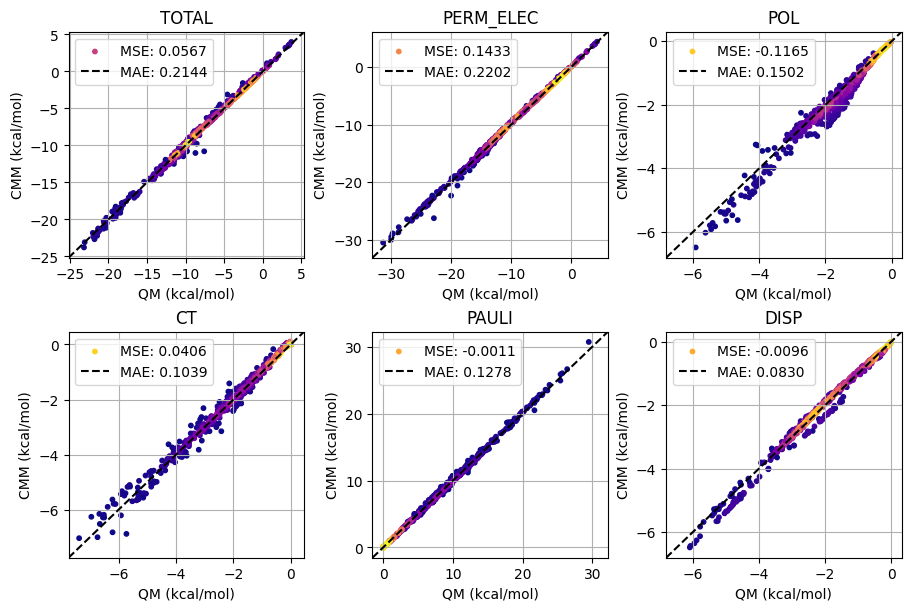

In [17]:
fig = report_eda_cluster(trainer, data)